## Resumen
Este notebook evalua escenarios de valores extremos en Malawi 1997 (deteccion, trimming y winsorizacion), reconstruye bins para cada escenario y compara el impacto en media y top tail frente a GlobalDist.

Setup

In [18]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

Path

In [ ]:
ROOT = Path(".").resolve()
INPUT = ROOT / "01-input"
OUT = ROOT / "work"

mwi_path = INPUT / "country" / "MWI_1997.dta"
global_bins_path = INPUT / "GlobalDist1000bins_1990_2026_20260324_2021_01_02_PROD.dta"
pip_path = INPUT / "pip_1kbins.dta"

mwi_path, global_bins_path, pip_path

(PosixPath('/Users/danielaavayu/Desktop/World Bank/Bottom Coding/01-input/country/MWI_1997.dta'),
 PosixPath('/Users/danielaavayu/Desktop/World Bank/Bottom Coding/01-input/GlobalDist1000bins_1990_2026_20260324_2021_01_02_PROD.dta'),
 PosixPath('/Users/danielaavayu/Desktop/World Bank/Bottom Coding/01-input/pip_1kbins.dta'))

Load Microdata and Convert Welfare

In [20]:
mwi_raw = pd.read_stata(mwi_path, convert_categoricals=False)

cpi2021 = mwi_raw["cpi2021"].dropna().iloc[0]
icp2021 = mwi_raw["icp2021"].dropna().iloc[0]

mwi = mwi_raw[["welfare", "weight"]].dropna().copy()
mwi = mwi[mwi["weight"] > 0].copy()

mwi["welfare_2021ppp_day"] = mwi["welfare"] / (cpi2021 * icp2021 * 365)

mwi[["welfare", "welfare_2021ppp_day", "weight"]].describe()

,welfare,welfare_2021ppp_day,weight
count,"10,698.000000","10,698.000000","10,698.000000"
mean,"23,388.511719",10.553808,903.593933
std,"1,174,402.625000",529.936157,608.497070
min,448.985657,0.202600,59.504238
25%,"3,988.151855",1.799609,459.908325
50%,"6,036.379883",2.723850,778.125000
75%,"9,712.176270",4.382512,"1,185.886475"
max,"118,420,360.000000","53,435.875000","6,765.000000"


Load fixed benchmarks

In [21]:
pip = pd.read_stata(pip_path, convert_categoricals=False)
pip["year"] = pip["year"].astype(int)

mwi_pip_row = pip[
    (pip["country_code"] == "MWI")
    & (pip["year"] == 1997)
].iloc[0]

pip_mean = mwi_pip_row["mean"]
global_1kbins_mean = mwi_pip_row["mean_1kbins"]

pd.DataFrame({
    "source": ["PIP mean", "Global 1000-bin mean"],
    "mean": [pip_mean, global_1kbins_mean],
})

,source,mean
0,PIP mean,5.724018
1,Global 1000-bin mean,4.865801


Load Global 1000 Bins For Malawi 1997

In [22]:
chunks = []

for chunk in pd.read_stata(
    global_bins_path,
    columns=["code", "year", "quantile", "welf", "pop"],
    chunksize=500_000,
):
    chunk["year"] = chunk["year"].astype(int)

    keep = (
        (chunk["code"] == "MWI")
        & (chunk["year"] == 1997)
    )

    if keep.any():
        chunks.append(chunk.loc[keep].copy())

mwi_global_bins = pd.concat(chunks, ignore_index=True)
mwi_global_bins["quantile"] = mwi_global_bins["quantile"].astype(float)

mwi_global_bins.head(), mwi_global_bins.tail()

(  code  year  quantile     welf      pop
 0  MWI  1997  1.000000 0.313979 0.010562
 1  MWI  1997  2.000000 0.353957 0.010562
 2  MWI  1997  3.000000 0.393859 0.010562
 3  MWI  1997  4.000000 0.416352 0.010562
 4  MWI  1997  5.000000 0.435401 0.010562,
     code  year     quantile         welf      pop
 995  MWI  1997   996.000000    46.885646 0.010562
 996  MWI  1997   997.000000    56.900297 0.010562
 997  MWI  1997   998.000000    70.545418 0.010562
 998  MWI  1997   999.000000    82.738549 0.010562
 999  MWI  1997 1,000.000000 1,296.486318 0.010562)

Equal-Population Bin Function

In [23]:
def weighted_equal_bins(df, value_col, weight_col, n_bins=1000):
    d = df[[value_col, weight_col]].dropna().copy()
    d = d[d[weight_col] > 0].sort_values(value_col).reset_index(drop=True)

    values = d[value_col].to_numpy(dtype=float)
    weights = d[weight_col].to_numpy(dtype=float)

    total_weight = weights.sum()
    bin_weight = total_weight / n_bins

    out = []
    i = 0
    remaining_weight_current_obs = weights[0]

    for b in range(1, n_bins + 1):
        needed = bin_weight
        numerator = 0.0
        denominator = 0.0

        while needed > 1e-10 and i < len(values):
            take = min(remaining_weight_current_obs, needed)

            numerator += values[i] * take
            denominator += take

            needed -= take
            remaining_weight_current_obs -= take

            if remaining_weight_current_obs <= 1e-10:
                i += 1
                if i < len(values):
                    remaining_weight_current_obs = weights[i]

        out.append({
            "quantile": float(b),
            "survey_bin_welf": numerator / denominator,
            "survey_bin_weight": denominator,
        })

    return pd.DataFrame(out)

Belotti-Style Extreme Values Detection

In [24]:
mwi_ev = mwi.copy()

# Belotti, Mancini and Vecchi-style logic:
# transform welfare first, then detect extreme values using robust z-scores.
mwi_ev["log_welfare"] = np.log(mwi_ev["welfare_2021ppp_day"])

median_log = mwi_ev["log_welfare"].median()
mad_log = np.median(np.abs(mwi_ev["log_welfare"] - median_log))

# Scale MAD to be comparable to SD under normality
scale_log = 1.4826 * mad_log

alpha = 3

mwi_ev["robust_z_log"] = (
    mwi_ev["log_welfare"] - median_log
) / scale_log

mwi_ev["top_outlier_ev"] = mwi_ev["robust_z_log"] > alpha

ev_summary = pd.DataFrame({
    "stat": [
        "median_log",
        "mad_log",
        "scale_log",
        "alpha",
        "n_observations",
        "n_top_outliers",
        "share_top_outliers_unweighted",
        "weighted_population",
        "weighted_population_top_outliers",
        "share_top_outliers_weighted",
    ],
    "value": [
        median_log,
        mad_log,
        scale_log,
        alpha,
        len(mwi_ev),
        mwi_ev["top_outlier_ev"].sum(),
        mwi_ev["top_outlier_ev"].mean(),
        mwi_ev["weight"].sum(),
        mwi_ev.loc[mwi_ev["top_outlier_ev"], "weight"].sum(),
        mwi_ev.loc[mwi_ev["top_outlier_ev"], "weight"].sum() / mwi_ev["weight"].sum(),
    ],
})

ev_summary

,stat,value
0,median_log,1.002046
1,mad_log,0.440375
2,scale_log,0.652901
3,alpha,3.000000
4,n_observations,"10,698.000000"
5,n_top_outliers,221.000000
6,share_top_outliers_unweighted,0.020658
7,weighted_population,"9,666,648.000000"
8,weighted_population_top_outliers,"154,656.562500"
9,share_top_outliers_weighted,0.015999


Inspect Flagged Extreme Values

In [25]:
mwi_ev.loc[mwi_ev["top_outlier_ev"]].sort_values(
    "welfare_2021ppp_day",
    ascending=False
).head(30)

,welfare,weight,welfare_2021ppp_day,log_welfare,robust_z_log,top_outlier_ev
7694,"118,420,360.000000",324.366119,"53,435.875000",10.886237,15.138891,True
10462,"27,006,552.000000",148.399994,"12,186.407227",9.408076,12.874901,True
9843,"1,204,712.375000",151.021271,543.613098,6.298238,8.111788,True
7269,"981,653.625000","1,827.431274",442.960327,6.093480,7.798176,True
9812,"713,340.875000",75.510635,321.887177,5.774201,7.309159,True
7379,"428,542.312500",261.061615,193.374969,5.264631,6.528689,True
7120,"374,757.750000","1,305.308105",169.105286,5.130521,6.323283,True
1503,"346,888.031250",196.686447,156.529388,5.053244,6.204922,True
1487,"345,174.093750",983.432251,155.755981,5.048291,6.197336,True
7124,"288,622.625000",261.061615,130.237762,4.869362,5.923284,True


Create Trimmed And Winsorized Versions

In [26]:
# 1. Trimmed: drop observations flagged as top outliers
mwi_ev_trimmed = mwi_ev.loc[~mwi_ev["top_outlier_ev"]].copy()

# 2. Winsorized: replace values above the cutoff with the cutoff
upper_log_cutoff = median_log + alpha * scale_log
upper_welfare_cutoff = np.exp(upper_log_cutoff)

mwi_ev_winsor = mwi_ev.copy()
mwi_ev_winsor["welfare_2021ppp_day_original"] = mwi_ev_winsor["welfare_2021ppp_day"]

mwi_ev_winsor["welfare_2021ppp_day"] = np.minimum(
    mwi_ev_winsor["welfare_2021ppp_day"],
    upper_welfare_cutoff,
)

upper_welfare_cutoff

np.float32(19.31241)

Rebuild Bins Under Each Scenario

In [27]:
bins_original = weighted_equal_bins(
    mwi,
    value_col="welfare_2021ppp_day",
    weight_col="weight",
    n_bins=1000,
)

bins_ev_trimmed = weighted_equal_bins(
    mwi_ev_trimmed,
    value_col="welfare_2021ppp_day",
    weight_col="weight",
    n_bins=1000,
)

bins_ev_winsor = weighted_equal_bins(
    mwi_ev_winsor,
    value_col="welfare_2021ppp_day",
    weight_col="weight",
    n_bins=1000,
)

Compare Means

In [28]:
def weighted_mean(df, value_col="welfare_2021ppp_day", weight_col="weight"):
    return np.average(df[value_col], weights=df[weight_col])

def bin_mean(bins):
    return np.average(
        bins["survey_bin_welf"],
        weights=bins["survey_bin_weight"],
    )

mean_comparison_ev = pd.DataFrame({
    "source": [
        "PIP mean",
        "Global 1000-bin mean",
        "Microdata original, direct weighted mean",
        "Microdata original, rebuilt bins",
        "EV trimmed, direct weighted mean",
        "EV trimmed, rebuilt bins",
        "EV winsorized, direct weighted mean",
        "EV winsorized, rebuilt bins",
    ],
    "mean": [
        pip_mean,
        global_1kbins_mean,
        weighted_mean(mwi),
        bin_mean(bins_original),
        weighted_mean(mwi_ev_trimmed),
        bin_mean(bins_ev_trimmed),
        weighted_mean(mwi_ev_winsor),
        bin_mean(bins_ev_winsor),
    ],
})

mean_comparison_ev["difference_vs_pip"] = mean_comparison_ev["mean"] - pip_mean
mean_comparison_ev["difference_vs_global_1kbins"] = (
    mean_comparison_ev["mean"] - global_1kbins_mean
)

mean_comparison_ev

,source,mean,difference_vs_pip,difference_vs_global_1kbins
0,PIP mean,5.724018,0.000000,0.858217
1,Global 1000-bin mean,4.865801,-0.858217,0.000000
2,"Microdata original, direct weighted mean",5.779648,0.055630,0.913847
3,"Microdata original, rebuilt bins",5.779648,0.055630,0.913847
4,"EV trimmed, direct weighted mean",3.099092,-2.624926,-1.766709
5,"EV trimmed, rebuilt bins",3.099092,-2.624926,-1.766709
6,"EV winsorized, direct weighted mean",3.358489,-2.365529,-1.507312
7,"EV winsorized, rebuilt bins",3.358489,-2.365529,-1.507312


Compare Top Bin Across Scenarios

In [29]:
topbin_comparison_ev = pd.DataFrame({
    "scenario": [
        "Original rebuilt bins",
        "EV trimmed rebuilt bins",
        "EV winsorized rebuilt bins",
        "Global precomputed bins",
    ],
    "bin_1000_mean": [
        bins_original.loc[bins_original["quantile"] == 1000, "survey_bin_welf"].iloc[0],
        bins_ev_trimmed.loc[bins_ev_trimmed["quantile"] == 1000, "survey_bin_welf"].iloc[0],
        bins_ev_winsor.loc[bins_ev_winsor["quantile"] == 1000, "survey_bin_welf"].iloc[0],
        mwi_global_bins.loc[mwi_global_bins["quantile"] == 1000, "welf"].iloc[0],
    ],
})

topbin_comparison_ev["difference_vs_global_topbin"] = (
    topbin_comparison_ev["bin_1000_mean"]
    - mwi_global_bins.loc[mwi_global_bins["quantile"] == 1000, "welf"].iloc[0]
)

topbin_comparison_ev

,scenario,bin_1000_mean,difference_vs_global_topbin
0,Original rebuilt bins,"2,172.696974",876.210656
1,EV trimmed rebuilt bins,18.773948,"-1,277.712370"
2,EV winsorized rebuilt bins,19.312410,"-1,277.173908"
3,Global precomputed bins,"1,296.486318",0.000000


Bin-By-Bin Comparison For Winsorized Scenario

In [30]:
comparison_ev_winsor = bins_ev_winsor.merge(
    mwi_global_bins[["quantile", "welf", "pop"]],
    on="quantile",
    how="left",
).rename(columns={
    "welf": "global_bin_welf",
    "pop": "global_bin_pop",
})

comparison_ev_winsor["diff_survey_minus_global"] = (
    comparison_ev_winsor["survey_bin_welf"]
    - comparison_ev_winsor["global_bin_welf"]
)

comparison_ev_winsor["ratio_survey_global"] = (
    comparison_ev_winsor["survey_bin_welf"]
    / comparison_ev_winsor["global_bin_welf"]
)

comparison_ev_winsor.tail(20)

,quantile,survey_bin_welf,survey_bin_weight,global_bin_welf,global_bin_pop,diff_survey_minus_global,ratio_survey_global
980,981.000000,16.825466,"9,666.648092",16.645980,0.010562,0.179486,1.010783
981,982.000000,17.743992,"9,666.648092",17.557167,0.010562,0.186825,1.010641
982,983.000000,18.293875,"9,666.648092",18.084843,0.010562,0.209031,1.011558
983,984.000000,18.767636,"9,666.648092",18.570331,0.010562,0.197304,1.010625
984,985.000000,19.312406,"9,666.648092",19.451648,0.010562,-0.139242,0.992842
985,986.000000,19.312410,"9,666.648092",20.724538,0.010562,-1.412128,0.931862
986,987.000000,19.312410,"9,666.648092",21.423881,0.010562,-2.111470,0.901443
987,988.000000,19.312410,"9,666.648092",21.896685,0.010562,-2.584275,0.881979
988,989.000000,19.312410,"9,666.648092",22.744716,0.010562,-3.432306,0.849094
989,990.000000,19.312410,"9,666.648092",25.060238,0.010562,-5.747828,0.770640


Graph Top Tail

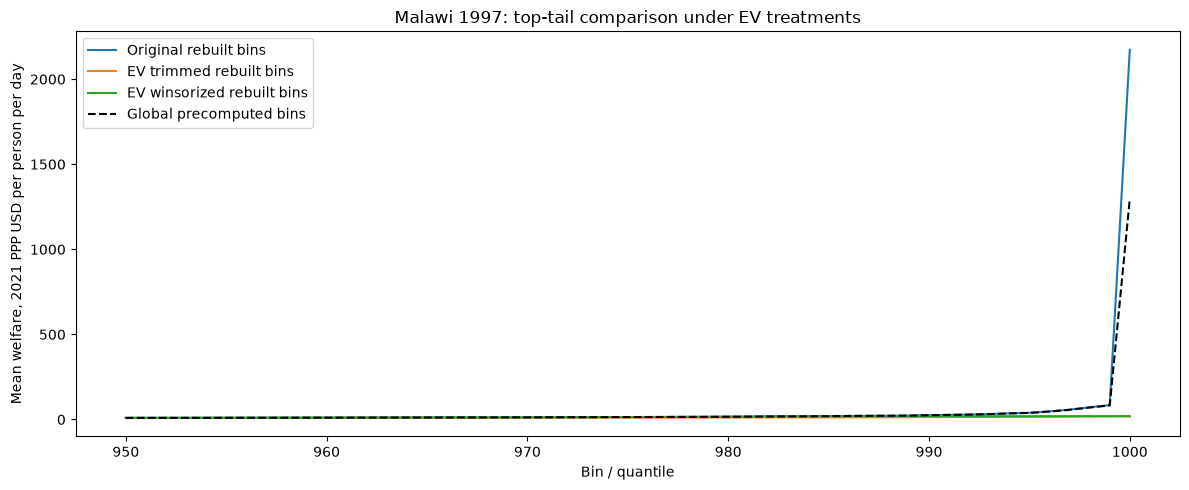

In [31]:
top_zoom_original = bins_original.merge(
    mwi_global_bins[["quantile", "welf"]],
    on="quantile",
    how="left",
).rename(columns={"welf": "global_bin_welf"})

top_zoom_trimmed = bins_ev_trimmed.merge(
    mwi_global_bins[["quantile", "welf"]],
    on="quantile",
    how="left",
).rename(columns={"welf": "global_bin_welf"})

top_zoom_winsor = bins_ev_winsor.merge(
    mwi_global_bins[["quantile", "welf"]],
    on="quantile",
    how="left",
).rename(columns={"welf": "global_bin_welf"})

fig, ax = plt.subplots(figsize=(12, 5))

for df_plot, label in [
    (top_zoom_original, "Original rebuilt bins"),
    (top_zoom_trimmed, "EV trimmed rebuilt bins"),
    (top_zoom_winsor, "EV winsorized rebuilt bins"),
]:
    sub = df_plot[df_plot["quantile"] >= 950]
    ax.plot(
        sub["quantile"],
        sub["survey_bin_welf"],
        label=label,
        linewidth=1.5,
    )

sub_global = top_zoom_original[top_zoom_original["quantile"] >= 950]
ax.plot(
    sub_global["quantile"],
    sub_global["global_bin_welf"],
    label="Global precomputed bins",
    linewidth=1.5,
    linestyle="--",
    color="black",
)

ax.set_title("Malawi 1997: top-tail comparison under EV treatments")
ax.set_xlabel("Bin / quantile")
ax.set_ylabel("Mean welfare, 2021 PPP USD per person per day")
ax.legend()

plt.tight_layout()
plt.show()

In [32]:
ev_summary.to_csv(OUT / "MWI_1997_ev_summary.csv", index=False)
mean_comparison_ev.to_csv(OUT / "MWI_1997_ev_mean_comparison.csv", index=False)
topbin_comparison_ev.to_csv(OUT / "MWI_1997_ev_topbin_comparison.csv", index=False)
comparison_ev_winsor.to_csv(OUT / "MWI_1997_ev_winsor_bins_vs_global.csv", index=False)
mwi_ev.loc[mwi_ev["top_outlier_ev"]].to_csv(
    OUT / "MWI_1997_ev_flagged_top_outliers.csv",
    index=False,
)

OUT

PosixPath('/Users/danielaavayu/Desktop/World Bank/Bottom Coding/work')